In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%matplotlib inline

In [3]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [4]:
np.random.seed(3465)
n_neur=30
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(30, 30)

In [5]:
np.random.seed(111)
mask = np.random.random((A.shape[0],A.shape[1]))>0.55
np.fill_diagonal(mask,1)
B = np.multiply(A,1-mask)
A = np.multiply(A,mask)

In [6]:
def continuous_noise_fun(num, l=5000):
    xx = np.linspace(0,500,l)
    noise = np.zeros((num,l))
    for i in range(num):
        a = 2*np.random.normal(0,0.25,size=6)
        c = 500*(np.random.random(size=6))
        s = 1+100*(np.random.random(size=6))
        yy = 0*xx
        for j in range(6):
            yy = yy + a[j]*np.exp(-(xx-c[j])**2/s[j]) 
        noise[i] = yy
    return noise 
np.random.seed(13)

noise = continuous_noise_fun(num=n_neur, l=5000)

In [7]:
noise.shape

(30, 5000)

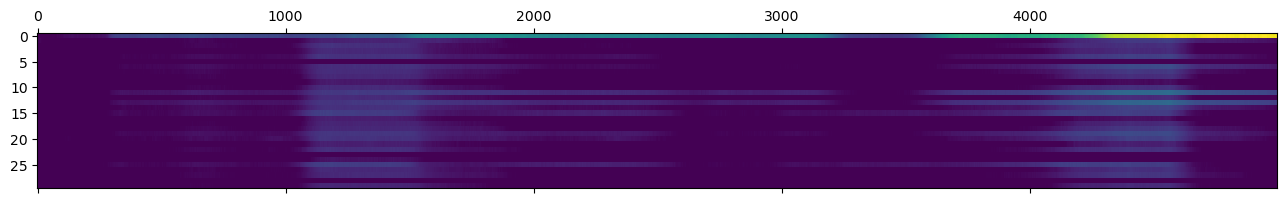

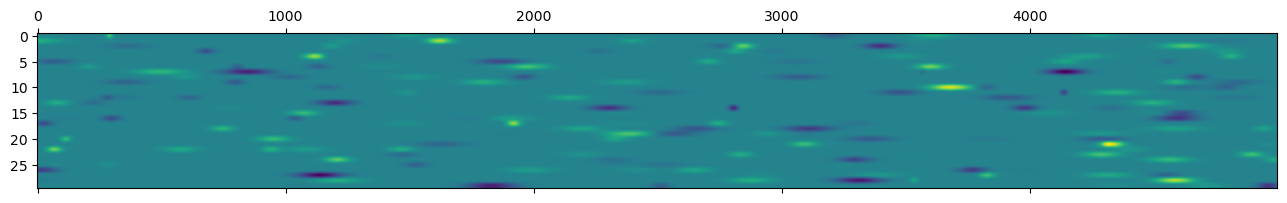

In [8]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A @ X[i] + B @ X[i-1] + np.random.normal(0,0.25,A.shape[0]) + noise[:,i]
X=X.T
plt.matshow(X, aspect='auto',vmin=0)
plt.matshow(noise, aspect='auto', interpolation=None)

## Analysis

In [9]:
N_PASTS, n_lags, n_perm = np.arange(2, 8, 1), 2, 1000
alpha, beta = 0.01, 0.001

In [ ]:
%%time
metrics = np.zeros((7,4))
infs = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
    gcstar.fit(X, verbose = 0)
    
    infs.append(gcstar.get_connectivity_matrix(simulation=True))
    gcstar.plot_extended_connectivity_matrix()
    gcstar.compute_confusion_matrix(np.logical_or(A,B), simulation = True)
    metrics[i] =  gcstar.compute_metrics()

2 pasts
3 pasts
4 pasts
5 pasts


In [ ]:
metrics

In [ ]:
labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(1, 8, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()

In [ ]:
def mat_func(A,inf):
    return 40*np.logical_and(A!=0,inf!=0) + 30*np.logical_and(A==0,inf!=0) + 20*np.logical_and(A!=0,inf==0)+10*np.logical_and(A==0,inf==0)



In [ ]:
for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(mat_func(A.T, el))
    plt.title(f'{i+1} pasts')

In [ ]:
def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FN_inf],
                     [FP_inf,TN_inf]])


In [ ]:
%matplotlib inline
import seaborn as sns
fig,axes = plt.subplots(7, 1, figsize=(4,20))
for i, ax in enumerate(axes):
    conf = confusion_matrix(infs[i], A.T)
    print(conf)
    g1 = sns.heatmap(conf, annot=True, ax=ax)